# Wave Equation and Numerical Dispersion

For $u_{tt}=c^2u_{xx}$, the exact phase speed is frequency-independent ($\omega=ck$).  
Discrete schemes introduce modified dispersion:
$$
\sin^2\!\left(\frac{\omega\Delta t}{2}\right)
= r^2\sin^2\!\left(\frac{k\Delta x}{2}\right),\quad r=\frac{c\Delta t}{\Delta x}.
$$
This notebook compares analytical and numerical behavior.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/wave-equation-dispersion") if Path("python/wave-equation-dispersion").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Leapfrog finite-difference solver

We propagate a two-frequency wave packet and inspect long-time phase distortion.


In [2]:
n = 500
L = 2*np.pi
x = np.linspace(0, L, n, endpoint=False)
dx = x[1] - x[0]
c = 1.0
r = 0.95
dt = r * dx / c
T = 7.0
n_steps = int(T / dt)

u0 = np.exp(-((x-1.5)/0.5)**2) * (np.sin(8*x) + 0.65*np.sin(18*x))
v0 = np.zeros_like(x)

u_prev = u0 - dt*v0 + 0.5*(c*dt/dx)**2*(np.roll(u0,-1)-2*u0+np.roll(u0,1))
u = u0.copy()

snap_ids = [0, n_steps//3, 2*n_steps//3, n_steps]
snaps = {0: u0.copy()}
for it in range(1, n_steps+1):
    u_next = 2*u - u_prev + (c*dt/dx)**2*(np.roll(u,-1)-2*u+np.roll(u,1))
    u_prev, u = u, u_next
    if it in snap_ids:
        snaps[it] = u.copy()


## Compare simulated wave evolution and discrete phase velocity

We plot snapshots and the ratio $v_p^\text{num}(k)/c$ predicted by the scheme dispersion relation.


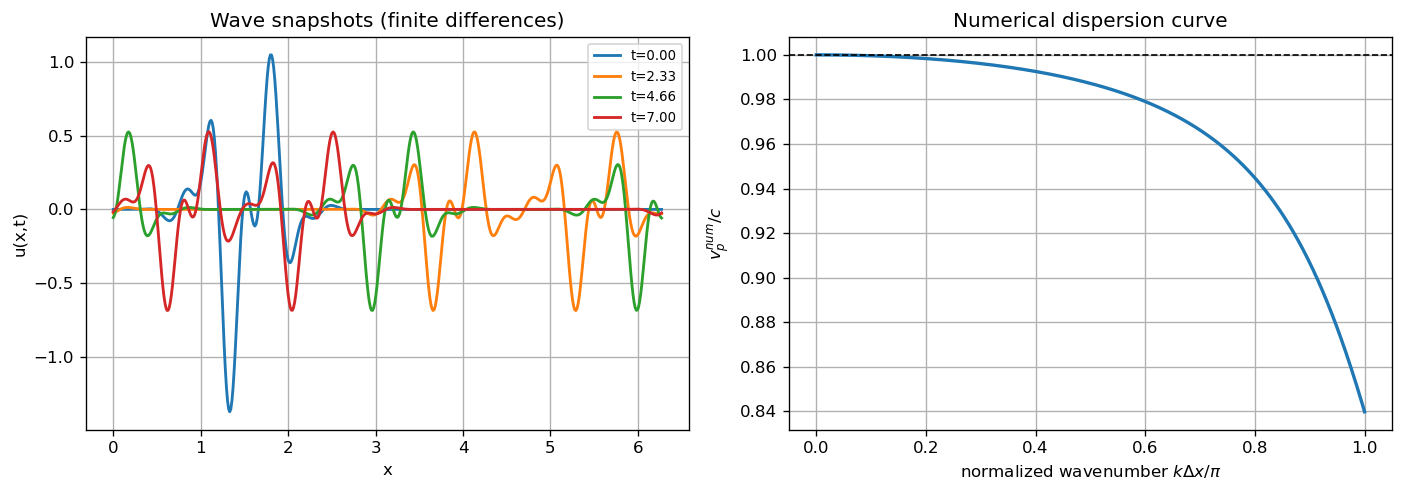

In [3]:
k = np.linspace(1e-4, np.pi/dx, 700)
omega_num = (2/dt) * np.arcsin(np.clip(r*np.sin(0.5*k*dx), -1, 1))
vp_ratio = omega_num / (c*k)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))
for it in snap_ids:
    axes[0].plot(x, snaps[it], lw=1.7, label=f"t={it*dt:.2f}")
axes[0].set_title("Wave snapshots (finite differences)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x,t)")
axes[0].legend(fontsize=8)

axes[1].plot(k*dx/np.pi, vp_ratio, lw=2)
axes[1].axhline(1.0, ls="--", color="k", lw=1)
axes[1].set_xlabel(r"normalized wavenumber $k\Delta x/\pi$")
axes[1].set_ylabel(r"$v_p^{num}/c$")
axes[1].set_title("Numerical dispersion curve")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- C. Villani, *Topics in Optimal Transportation*.
- G. Peyré and M. Cuturi, *Computational Optimal Transport*.
- J. D. Murray, *Mathematical Biology* (for pattern-forming PDEs).
- R. J. LeVeque, *Finite Difference Methods for ODEs and PDEs*.
